In [1]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [19]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir: Path
    source_URL: str
    local_data_file: Path
    scale: str
    out: Path
    z_idx: tuple
    y_idx: tuple
    x_idx: tuple

In [4]:
from src.task2 import logger
from src.task2.constants import *
from src.task2.utils.common import read_yaml, create_directories

In [23]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_data_ingestion_config(self) -> DataIngestionConfig:
        config = self.config.data_ingestion

        create_directories([config.root_dir])

        data_ingestion_config = DataIngestionConfig(
            root_dir= Path(config.root_dir),
            source_URL= str(config.source_URL),
            local_data_file=Path(config.local_data_file),
            scale= str(self.params.scale),
            out= Path(config.OUTPUT),
            z_idx= tuple(self.params.z_idx),
            y_idx= tuple(self.params.y_idx),
            x_idx= tuple(self.params.x_idx),

        )

        return data_ingestion_config

In [6]:
import os
import numpy as np
import fibsem_tools as fst
import xarray as xr
import s3fs
from pathlib import Path
from src.task2 import logger
from src.task2.utils.common import get_size

In [7]:
import datetime
import zarr

In [21]:
class DataIngestion:
    def __init__(self, config: DataIngestionConfig):
        self.config = config

    
    def download_file(self)-> str:
        '''
        Fetch data from the url
        '''

        try: 
            dataset_url = self.config.source_URL
            local_file_path= self.config.local_data_file
            scale=self.config.scale

            os.makedirs(os.path.dirname(local_file_path), exist_ok=True)
            # 2. Check if file already exists to save time/bandwidth
            if not os.path.exists(local_file_path):
                logger.info(f"Connecting to s3 {dataset_url}...")

                tree = fst.read_xarray(dataset_url, storage_options={'anon': True})

                with open(self.config.out, 'a') as f:
                    f.write(f"Node {scale} Value: {tree[scale]}\n")
                    f.write("-"*30+'\n')
                
                data_array = tree[scale].data
                logger.info(f"Fetching chunks from S3 {scale}...")
                # Based on your metadata chunksize of 448
                z_range = slice(self.config.z_idx[0], self.config.z_idx[1])       # 2 vertical chunks
                y_range = slice(self.config.y_idx[0], self.config.y_idx[1])   # 1 chunk wide
                x_range = slice(self.config.x_idx[0], self.config.x_idx[1])   # 1 chunk deep

                # .compute() pulls the data from S3 into memory
                volume = data_array[z_range, y_range, x_range].compute()
                # 5. Save as .npy for fast loading into DINO v3
                np.save(local_file_path, volume)
                logger.info(f"Download complete! Volume {volume.shape} saved to: {local_file_path} (Size: {get_size(Path(local_file_path))})")
            else:
                logger.info(f"File already exists at: {local_file_path} (Size: {get_size(Path(local_file_path))})")
        except Exception as e:
            logger.error(f"Error occurred while downloading: {e}")
            raise e
    # def download_file_zarr(self)-> str:
    #     try:
    #         fs = s3fs.S3FileSystem(anon=True)
    #         scale = self.config.scale
    #         s3_path = os.path.join(self.config.source_URL,scale)
    #         local_path = Path(self.config.local_data_file)
    #         if not local_path.exists():
    #             logger.info(f"Connecting to Zarr V2 at: {s3_path}")
    #             store = s3fs.S3Map(root=s3_path, s3=fs, check=False)
    #             z_array = zarr.open(store, mode='r')
    #             ds = xr.DataArray(
    #                 z_array, 
    #                 dims=("z", "y", "x"), 
    #                 name="t_cell_em"
    #             )
    #             roi = ds.isel(
    #             z=slice(4872, 5320), 
    #             y=slice(587, 1035), 
    #             x=slice(3487, 3935)
    #             )
    #             logger.info(f"Computing Dask graph for {scale} ROI...")
    #             volume_np = roi.values
    #             local_path.parent.mkdir(parents=True, exist_ok=True)
    #             np.save(local_path, volume_np)
    #             logger.info(f"ROI saved successfully to {local_path}")
    #         return str(local_path)
    #     except Exception as e:
    #         logger.error(f"Lazy download failed: {e}")
    #         raise e


    def data_dim(self):
        data = np.load(self.config.local_data_file, mmap_mode='r')
        dd={
            "Shape": list(data.shape), 
            "Dtype": str(data.dtype), 
            "Total Elements": int(data.size),
            "Memory Size MB": float(f"{data.nbytes / (1024**2):.2f}")
        }
        with open(self.config.out, 'a') as f:
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            f.write(f"\n--- Analysis Run: {timestamp} ---\n")
            f.write(f"Data Summary for {self.config.local_data_file}\n")
            f.write("-" * 30 + "\n")
            # for key, value in dd.items():
            #     f.write(f"{key}: {value}\n")
            f.write(f"Shape: {dd['Shape']}\n")
            f.write(f"Dtype: {dd['Dtype']}\n")
            f.write(f"Total Elements: {dd['Total Elements']:,}\n")
            f.write(f"Memory: {dd['Memory Size MB']} MB\n")
            f.write("-" * 30 + "\n")
        logger.info("Created and stored Data Summary")

In [24]:
try:
    config = ConfigurationManager()
    data_ingestion_config = config.get_data_ingestion_config()
    data_ingestion = DataIngestion(config=data_ingestion_config)
    data_ingestion.download_file()
    # data_ingestion.download_file_zarr()
    data_ingestion.data_dim()
except Exception as e:
    raise e

[2026-04-05 09:56:37,300: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-04-05 09:56:37,338: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-05 09:56:37,349: INFO: common: created directory at: artifacts]
[2026-04-05 09:56:37,350: INFO: common: created directory at: artifacts/data_ingestion]
[2026-04-05 09:56:37,351: INFO: 2366882192: Connecting to s3 s3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/...]


/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


[2026-04-05 09:56:45,879: INFO: 2366882192: Fetching chunks from S3 s0...]
[2026-04-05 09:57:03,238: INFO: 2366882192: Download complete! Volume (448, 448, 448) saved to: artifacts/data_ingestion/liver_chunk1_s0.npy (Size: ~ 87808 KB)]
[2026-04-05 09:57:03,253: INFO: 2366882192: Created and stored Data Summary]


# Trails

In [12]:
import quilt3 as q3
b = q3.Bucket("s3://janelia-cosem-datasets")
b.ls("jrc_mus-liver/jrc_mus-liver.zarr/")

([{'Prefix': 'jrc_mus-liver/jrc_mus-liver.zarr/recon-1/'}],
 [{'ETag': '"99914b932bd37a50b983c5e7c90ae93b"',
   'Size': 2,
   'StorageClass': 'STANDARD',
   'Key': 'jrc_mus-liver/jrc_mus-liver.zarr/.zattrs',
   'VersionId': 'null',
   'IsLatest': True,
   'LastModified': datetime.datetime(2024, 8, 1, 3, 42, 4, tzinfo=tzutc()),
   'Owner': {'ID': '00987910cca20cc0c9915bc698607c0e7dee9d16710c48e2d14a20f7a05d4fe5'}},
  {'ETag': '"e20297935e73dd0154104d4ea53040ab"',
   'Size': 24,
   'StorageClass': 'STANDARD',
   'Key': 'jrc_mus-liver/jrc_mus-liver.zarr/.zgroup',
   'VersionId': 'null',
   'IsLatest': True,
   'LastModified': datetime.datetime(2024, 8, 1, 3, 42, 4, tzinfo=tzutc()),
   'Owner': {'ID': '00987910cca20cc0c9915bc698607c0e7dee9d16710c48e2d14a20f7a05d4fe5'}}],
 [])

# From Fibsem-tools GitHub

In [22]:
from fibsem_tools import read_xarray, read
from rich import print # pretty printing
creds = {'anon': True} # anonymous credentials for s3
url = 's3://janelia-cosem-datasets/jrc_sum159-1/jrc_sum159-1.n5/em/fibsem-uint16/' # path to a group of arrays on s3
group = read(url, storage_options=creds) # this returns a zarr group, which in this case is a collection of arrays
print(tuple(group.arrays())) # this shows all the arrays in the group
# (
#     ('s0', <zarr.core.Array '/em/fibsem-uint16/s0' (7632, 2800, 16000) uint16 read-only>),
#     ('s1', <zarr.core.Array '/em/fibsem-uint16/s1' (3816, 1400, 8000) uint16 read-only>),
#     ('s2', <zarr.core.Array '/em/fibsem-uint16/s2' (1908, 700, 4000) uint16 read-only>),
#     ('s3', <zarr.core.Array '/em/fibsem-uint16/s3' (954, 350, 2000) uint16 read-only>),
#     ('s4', <zarr.core.Array '/em/fibsem-uint16/s4' (477, 175, 1000) uint16 read-only>),
#     ('s5', <zarr.core.Array '/em/fibsem-uint16/s5' (239, 88, 500) uint16 read-only>)
# )
tree = read_xarray(url, storage_options=creds) # read the group as a DataTree, a collection of xarray objects
print(tree)

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


(
    ('s0', <zarr.core.Array '/em/fibsem-uint16/s0' (7632, 2800, 16000) uint16 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint16/s1' (3816, 1400, 8000) uint16 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint16/s2' (1908, 700, 4000) uint16 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint16/s3' (954, 350, 2000) uint16 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint16/s4' (477, 175, 1000) uint16 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint16/s5' (239, 88, 500) uint16 read-only>)
)

<xarray.DataTree 'fibsem-uint16'>
Group: /
│   Attributes:
│       axes:             ['x', 'y', 'z']
│       multiscales:      [{'datasets': [{'path': 's0', 'transform': {'axes': ['z...
│       pixelResolution:  {'dimensions': [4.0, 4.0, 4.56], 'unit': 'nm'}
│       scales:           [[1, 1, 1], [2, 2, 2], [4, 4, 4], [8, 8, 8], [16, 16, 1...
│       units:            ['nm', 'nm', 'nm']
├── Group: /s0
│       Dimensions:  (z: 7632, y: 2800, x: 16000)
│       Coordinates:
│         * z        (z) float64 61kB 0.0 4.56 9.12 ... 3.479e+04 3.479e+04 3.48e+04
│         * y        (y) float64 22kB 0.0 4.0 8.0 12.0 ... 1.119e+04 1.119e+04 1.12e+04
│         * x        (x) float64 128kB 0.0 4.0 8.0 12.0 ... 6.399e+04 6.399e+04 6.4e+04
│       Data variables:
│           data     (z, y, x) uint16 684GB dask.array<chunksize=(384, 384, 384), meta=np.ndarray>
├── Group: /s1
│       Dimensions:  (z: 3816, y: 1400, x: 8000)
│       Coordinates:
│         * z        (z) float64 31kB 2.28 11.4 20.52 ... 3.478e+04 3.479e+04 3.48e+04
│         * y        (y) float64 11kB 2.0 10.0 18.0 ... 1.118e+04 1.119e+04 1.119e+04
│         * x        (x) float64 64kB 2.0 10.0 18.0 ... 6.398e+04 6.399e+04 6.399e+04
│       Data variables:
│           data     (z, y, x) uint16 85GB dask.array<chunksize=(384, 384, 384), meta=np.ndarray>
├── Group: /s2
│       Dimensions:  (z: 1908, y: 700, x: 4000)
│       Coordinates:
│         * z        (z) float64 15kB 6.84 25.08 43.32 ... 3.475e+04 3.477e+04 3.479e+04
│         * y        (y) float64 6kB 6.0 22.0 38.0 ... 1.116e+04 1.117e+04 1.119e+04
│         * x        (x) float64 32kB 6.0 22.0 38.0 ... 6.396e+04 6.397e+04 6.399e+04
│       Data variables:
│           data     (z, y, x) uint16 11GB dask.array<chunksize=(384, 384, 384), meta=np.ndarray>
├── Group: /s3
│       Dimensions:  (z: 954, y: 350, x: 2000)
│       Coordinates:
│         * z        (z) float64 8kB 15.96 52.44 88.92 ... 3.471e+04 3.474e+04 3.478e+04
│         * y        (y) float64 3kB 14.0 46.0 78.0 ... 1.112e+04 1.115e+04 1.118e+04
│         * x        (x) float64 16kB 14.0 46.0 78.0 ... 6.392e+04 6.395e+04 6.398e+04
│       Data variables:
│           data     (z, y, x) uint16 1GB dask.array<chunksize=(384, 350, 384), meta=np.ndarray>
├── Group: /s4
│       Dimensions:  (z: 477, y: 175, x: 1000)
│       Coordinates:
│         * z        (z) float64 4kB 34.2 107.2 180.1 ... 3.462e+04 3.469e+04 3.476e+04
│         * y        (y) float64 1kB 30.0 94.0 158.0 ... 1.104e+04 1.11e+04 1.117e+04
│         * x        (x) float64 8kB 30.0 94.0 158.0 ... 6.384e+04 6.39e+04 6.397e+04
│       Data variables:
│           data     (z, y, x) uint16 167MB dask.array<chunksize=(477, 175, 768), meta=np.ndarray>
└── Group: /s5
        Dimensions:  (z: 239, y: 88, x: 500)
        Coordinates:
          * z        (z) float64 2kB 70.68 216.6 362.5 ... 3.451e+04 3.465e+04 3.48e+04
          * y        (y) float64 704B 62.0 190.0 318.0 ... 1.094e+04 1.107e+04 1.12e+04
          * x        (x) float64 4kB 62.0 190.0 318.0 ... 6.368e+04 6.381e+04 6.393e+04
        Data variables:
            data     (z, y, x) uint16 21MB dask.array<chunksize=(239, 88, 500), meta=np.ndarray>

In [32]:
import fibsem_tools as fst

In [48]:

# url = 's3://janelia-cosem-datasets/jrc_hela-21/jrc_hela-21.n5/em/fibsem-uint8/'
url='s3://janelia-cosem-datasets/jrc_mus-pancreas-1/jrc_mus-pancreas-1.n5/em/fibsem-uint16'
tree = fst.read_xarray(url, storage_options={'anon': True})

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [33]:
# tree['s0']
# 'a' means append (adds to the end of the file)
with open('OUTPUT/segment_log.txt', 'w') as f:
    f.write(f"Node s0 Value: {tree['s0']}\n ****** {tree['s1']}")

In [49]:
tree['s0']

<xarray.DataTree 's0'>
Group: /s0
    Dimensions:  (z: 7312, y: 5000, x: 7500)
    Coordinates:
      * z        (z) float64 58kB 0.0 3.4 6.8 10.2 ... 2.485e+04 2.485e+04 2.486e+04
      * y        (y) float64 40kB 0.0 4.0 8.0 12.0 ... 1.999e+04 1.999e+04 2e+04
      * x        (x) float64 60kB 0.0 4.0 8.0 12.0 ... 2.999e+04 2.999e+04 3e+04
    Data variables:
        data     (z, y, x) uint16 548GB dask.array<chunksize=(384, 384, 384), meta=np.ndarray>

In [50]:
import fibsem_tools as fst

s1_data = tree['s0'].data
ad=450
z= 1678
y= 707
x= 1993
small_crop = s1_data[z:z+ad, y:y+ad, x:x+ad].compute()
save_name = 'artifacts/data_ingestion/ps0.npy'
np.save(save_name,small_crop)
print(f"Downloaded Shape: {small_crop.shape}")
print(f"Data Size: {small_crop.nbytes / (1024**2):.2f} MB")


Downloaded Shape: (450, 450, 450)
Data Size: 173.81 MB


In [34]:
tree['s1']

<xarray.DataTree 's1'>
Group: /s1
    Dimensions:  (z: 974, y: 625, x: 3125)
    Coordinates:
      * z        (z) float64 8kB 4.0 20.0 36.0 ... 1.554e+04 1.556e+04 1.557e+04
      * y        (y) float64 5kB 4.0 20.0 36.0 ... 9.956e+03 9.972e+03 9.988e+03
      * x        (x) float64 25kB 4.0 20.0 36.0 ... 4.996e+04 4.997e+04 4.999e+04
    Data variables:
        data     (z, y, x) uint8 2GB dask.array<chunksize=(448, 448, 448), meta=np.ndarray>

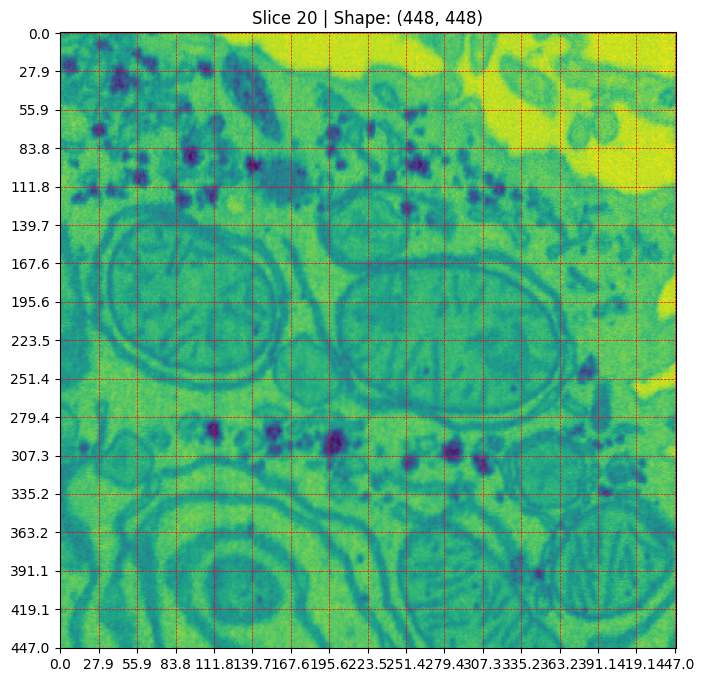

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_slice(file_path, slice_idx=None):
    
    data = np.load(file_path, mmap_mode='r')
    
    if slice_idx is None:
        slice_idx = data.shape[0] // 2

    img_slice = data[slice_idx]
    fig, ax =plt.subplots(figsize=(8, 8))
    ax.imshow(img_slice)
    plt.title(f"Slice {slice_idx} | Shape: {img_slice.shape}")
    grid_ticks = np.linspace(0, 447, 17)

    # 4. Set the ticks on both axes
    ax.set_xticks(grid_ticks)
    ax.set_yticks(grid_ticks)
    plt.grid(color='red', linestyle='--', linewidth=0.5)
    
    plt.show()

# Usage
visualize_slice('artifacts/data_ingestion/liver_chunk_s0.npy',slice_idx= 20)

In [4]:
import matplotlib.pyplot as plt
from ipywidgets import interact
data = np.load('artifacts/data_ingestion/ls1.npy', mmap_mode='r')
@interact(z=(0, data.shape[0]-1))
def show_slice(z):
    plt.imshow(data[z,:,:],cmap='grey')
    plt.title(f"Z-Index: {z}")
    plt.show()

interactive(children=(IntSlider(value=2, description='z', max=5), Output()), _dom_classes=('widget-interact',)…

In [1]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [55]:
import torch
if torch.backends.mps.is_available():
            torch.mps.empty_cache()
import gc
gc.collect()

20

In [52]:
import numpy as np
import os

# 1. Load the full volume (or use mmap_mode if it's too big)
data = np.load('artifacts/data_ingestion/ps0.npy', mmap_mode='r')

# 2. Extract your 10-slice "slab"
# This gets indices 340, 341, 342, 343, 344, 345, 346, 347, 348, 349
chunk_340_350 = data[442:448, : 448, :448].copy()

# 3. Save it as a new file
save_name = 'artifacts/data_ingestion/ps1.npy'
np.save(save_name, chunk_340_350)

print(f"Success! Saved {chunk_340_350.shape} volume to: {save_name}")

Success! Saved (6, 448, 448) volume to: artifacts/data_ingestion/ps1.npy


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Memory-map the volume to keep your M2 Pro fast
data = np.load('artifacts/data_ingestion/hela_cell_chunk_s0.npy', mmap_mode='r')

@interact(
    z=IntSlider(min=0, max=data.shape[0]-1, step=1, value=data.shape[0]//2),
    y=IntSlider(min=0, max=data.shape[1]-1, step=1, value=data.shape[1]//2),
    x=IntSlider(min=0, max=data.shape[2]-1, step=1, value=data.shape[2]//2)
)
def show_all_slices(z, y, x):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. XY Plane (Z-slice) - Standard Top-down view
    axes[0].imshow(data[z, :, :], cmap='gray', aspect=1.0)
    axes[0].set_title(f"XY Plane (Z={z})")
    axes[0].axhline(y, color='red', alpha=0.3) # Show where Y-slice is
    axes[0].axvline(x, color='green', alpha=0.3) # Show where X-slice is
    
    # 2. XZ Plane (Y-slice) - Frontal view
    # Note: aspect ratio adjustment for 3.44nm (Z) vs 4nm (X)
    axes[1].imshow(data[:, y, :], cmap='gray', aspect=3.44/4.0)
    axes[1].set_title(f"XZ Plane (Y={y})")
    axes[1].axhline(z, color='blue', alpha=0.3)
    
    # 3. YZ Plane (X-slice) - Lateral view
    # Note: aspect ratio adjustment for 3.44nm (Z) vs 4nm (Y)
    axes[2].imshow(data[:, :, x], cmap='gray', aspect=3.44/4.0)
    axes[2].set_title(f"YZ Plane (X={x})")
    axes[2].axhline(z, color='blue', alpha=0.3)

    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=144, description='z', max=287), IntSlider(value=144, description='y', ma…

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
data = np.load('artifacts/data_ingestion/ls1.npy', mmap_mode='r')
@interact(z=(0, data.shape[1]-1))
def show_slice(z):
    plt.figure(figsize=(6, 6))
    plt.imshow(data[z],cmap='grey')
    plt.title(f"Z-Index: {z}")
    plt.show()